## Setup

In [122]:
#utils I made to look at this data
import switchy.util as ut
import scanpy as sc
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl

import seaborn as sns
import autoreload
from nheatmap import nhm, scripts
import sklearn.decomposition, sklearn.cluster
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 300
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "outs"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

data_dir = "../../data/"
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Execution

In [12]:
# Load Data 
ab_tx, switch_tx = ut.loadSJoutIGH(data_dir + 'sj/CombinedSJouts_chr14_IGH.fthr')

filtering SJout to just IGH locus
making SJTable human readable


In [19]:
# Use only high quality cells
adata = sc.read_h5ad(data_dir + 'CombinedDivisionImmcantation.h5ad')
#adata.obs.index = adata.obs.index.str[:-2]
#Use Scanpy to filter for cells with good mapping and number of genes 
adata = ut.preprocessScanpy(adata, num_counted_reads=40000, num_genes=400, min_cells=5, n_neighbors= 15, num_highly_variable=1000)

making var_names unique
filtering cells with less than 40000 counted reads
filtering cells with less than 400 genes detected
filtering genes detected in less than 5
normalizing by total counts per cell
log transforming data
removed ERCC sequences from genes to cluster on
removing variable immune receptor genes which may drive clustering
calculating highly variable genes


Trying to set attribute `.var` of view, copying.


calculating PCA
creating neighbors graph with 15


/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/neighbors/__init__.py:121: FutureWarning: This location for 'distances' is deprecated. It has been moved to .obsp[distances], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['distances'] = neighbors.distances
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/neighbors/__init__.py:122: FutureWarning: This location for 'connectivities' is deprecated. It has been moved to .obsp[connectivities], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['connectivities'] = neighbors.connectivities
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/tools/_umap.py:147: FutureWarning: This location for 'connectivities' is deprecated. It has been moved to .obsp[connectivities], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['connectivities'].tocoo()

umapping and tsne-ing


In [126]:
adata.obs

,Donor,Experimental_Label,Treatment,Division_Number,CLONE,ISOTYPE,SEQUENCE_ID,Assembly,n_genes,n_counts
cell,,,,,,,,,,
CTY_I8,Donor_1,Activation_1,Activation,4,1160.0,IGHM,bracer_CTY_I8_TRINITY_DN0_c0_g1_i1_H Donor_1,AAGGTGTCCAGTGTGAAGTGCAGCTGGTGGAGTCTGGGGGAGGCTT...,7439,1453394.0
MS_SISTER2_J10,Donor_1,Activation_2,Activation,3,427.0,IGHD,bracer_MS_SISTER2_J10_TRINITY_DN2_c0_g3_i1_H D...,ATGGGTCCTGTCCCAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTG...,9518,977415.0
NaiveBcellsplate2_20180629_D23,Donor_1,Naive_1,Naive,100,248.0,IGHM,bracer_NaiveBcellsplate2_20180629_D23_TRINITY_...,GTCGTCAGATCTCAGGCTCCTCACCATGGACTGGACCTGGAGCATC...,2119,1155249.0
NaiveBcellsplate2_20180629_K4,Donor_1,Naive_1,Naive,100,40.0,nan,nan,nan,1267,391289.0
NaiveBcellsplate2_20180629_P1,Donor_1,Naive_1,Naive,100,565.0,IGHD,bracer_NaiveBcellsplate2_20180629_P1_TRINITY_D...,GTACATGGGGCTTTCTGAGAGTCATGGATCTCATGTGCAAGAAAAT...,2329,1139509.0
...,...,...,...,...,...,...,...,...,...,...
P1_5_23_19_D2_H8,Donor_2,Activation_4,Activation,7,1687.0,nan,nan,nan,3845,410208.0
P1_5_23_19_D2_A19,Donor_2,Activation_4,Activation,7,1149.0,IGHM,bracer_P1_5_23_19_D2_A19_TRINITY_DN4_c0_g1_i4_...,TCTGAGGATCTCCTGTAAGGGTTCTGGATACAGCTTTACCAGCTAC...,4573,2044758.0
P1_5_23_19_D2_M5,Donor_2,Activation_4,Activation,7,1618.0,IGHG2,bracer_P1_5_23_19_D2_M5_TRINITY_DN3_c1_g1_i1_H...,TGGTGGCAGCAGCTACAGGTGTCCAGTCCCAGGTGCAGCTGGTGCA...,3340,1034566.0


## SJout Analysis

In [123]:
adata

AnnData object with n_obs × n_vars = 1350 × 14714
    obs: 'Donor', 'Experimental_Label', 'Treatment', 'Division_Number', 'CLONE', 'ISOTYPE', 'SEQUENCE_ID', 'Assembly', 'n_genes', 'n_counts', 'Division_Category'
    var: 'n_cells', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p'

In [20]:
# Filter Sjout to be only cells which pass QC
ab_tx = ab_tx[ab_tx.cell.isin(adata.obs.index)]

switch_tx = switch_tx[switch_tx.cell.isin(adata.obs.index)]

In [21]:
switch_tx['exon_start'] = switch_tx['exon_start'].str.split('_', expand = True)[0]

In [22]:
def plotheatmap(df):
    sum_df = df.groupby(['cell', 'exon_start']).sum()
    sum_df['uniquelog2'] = np.log10(sum_df['unique_mapping'])
    ret_df = sum_df.uniquelog2.unstack().fillna(np.log10(1))
    sns.clustermap(ret_df)
    return ret_df

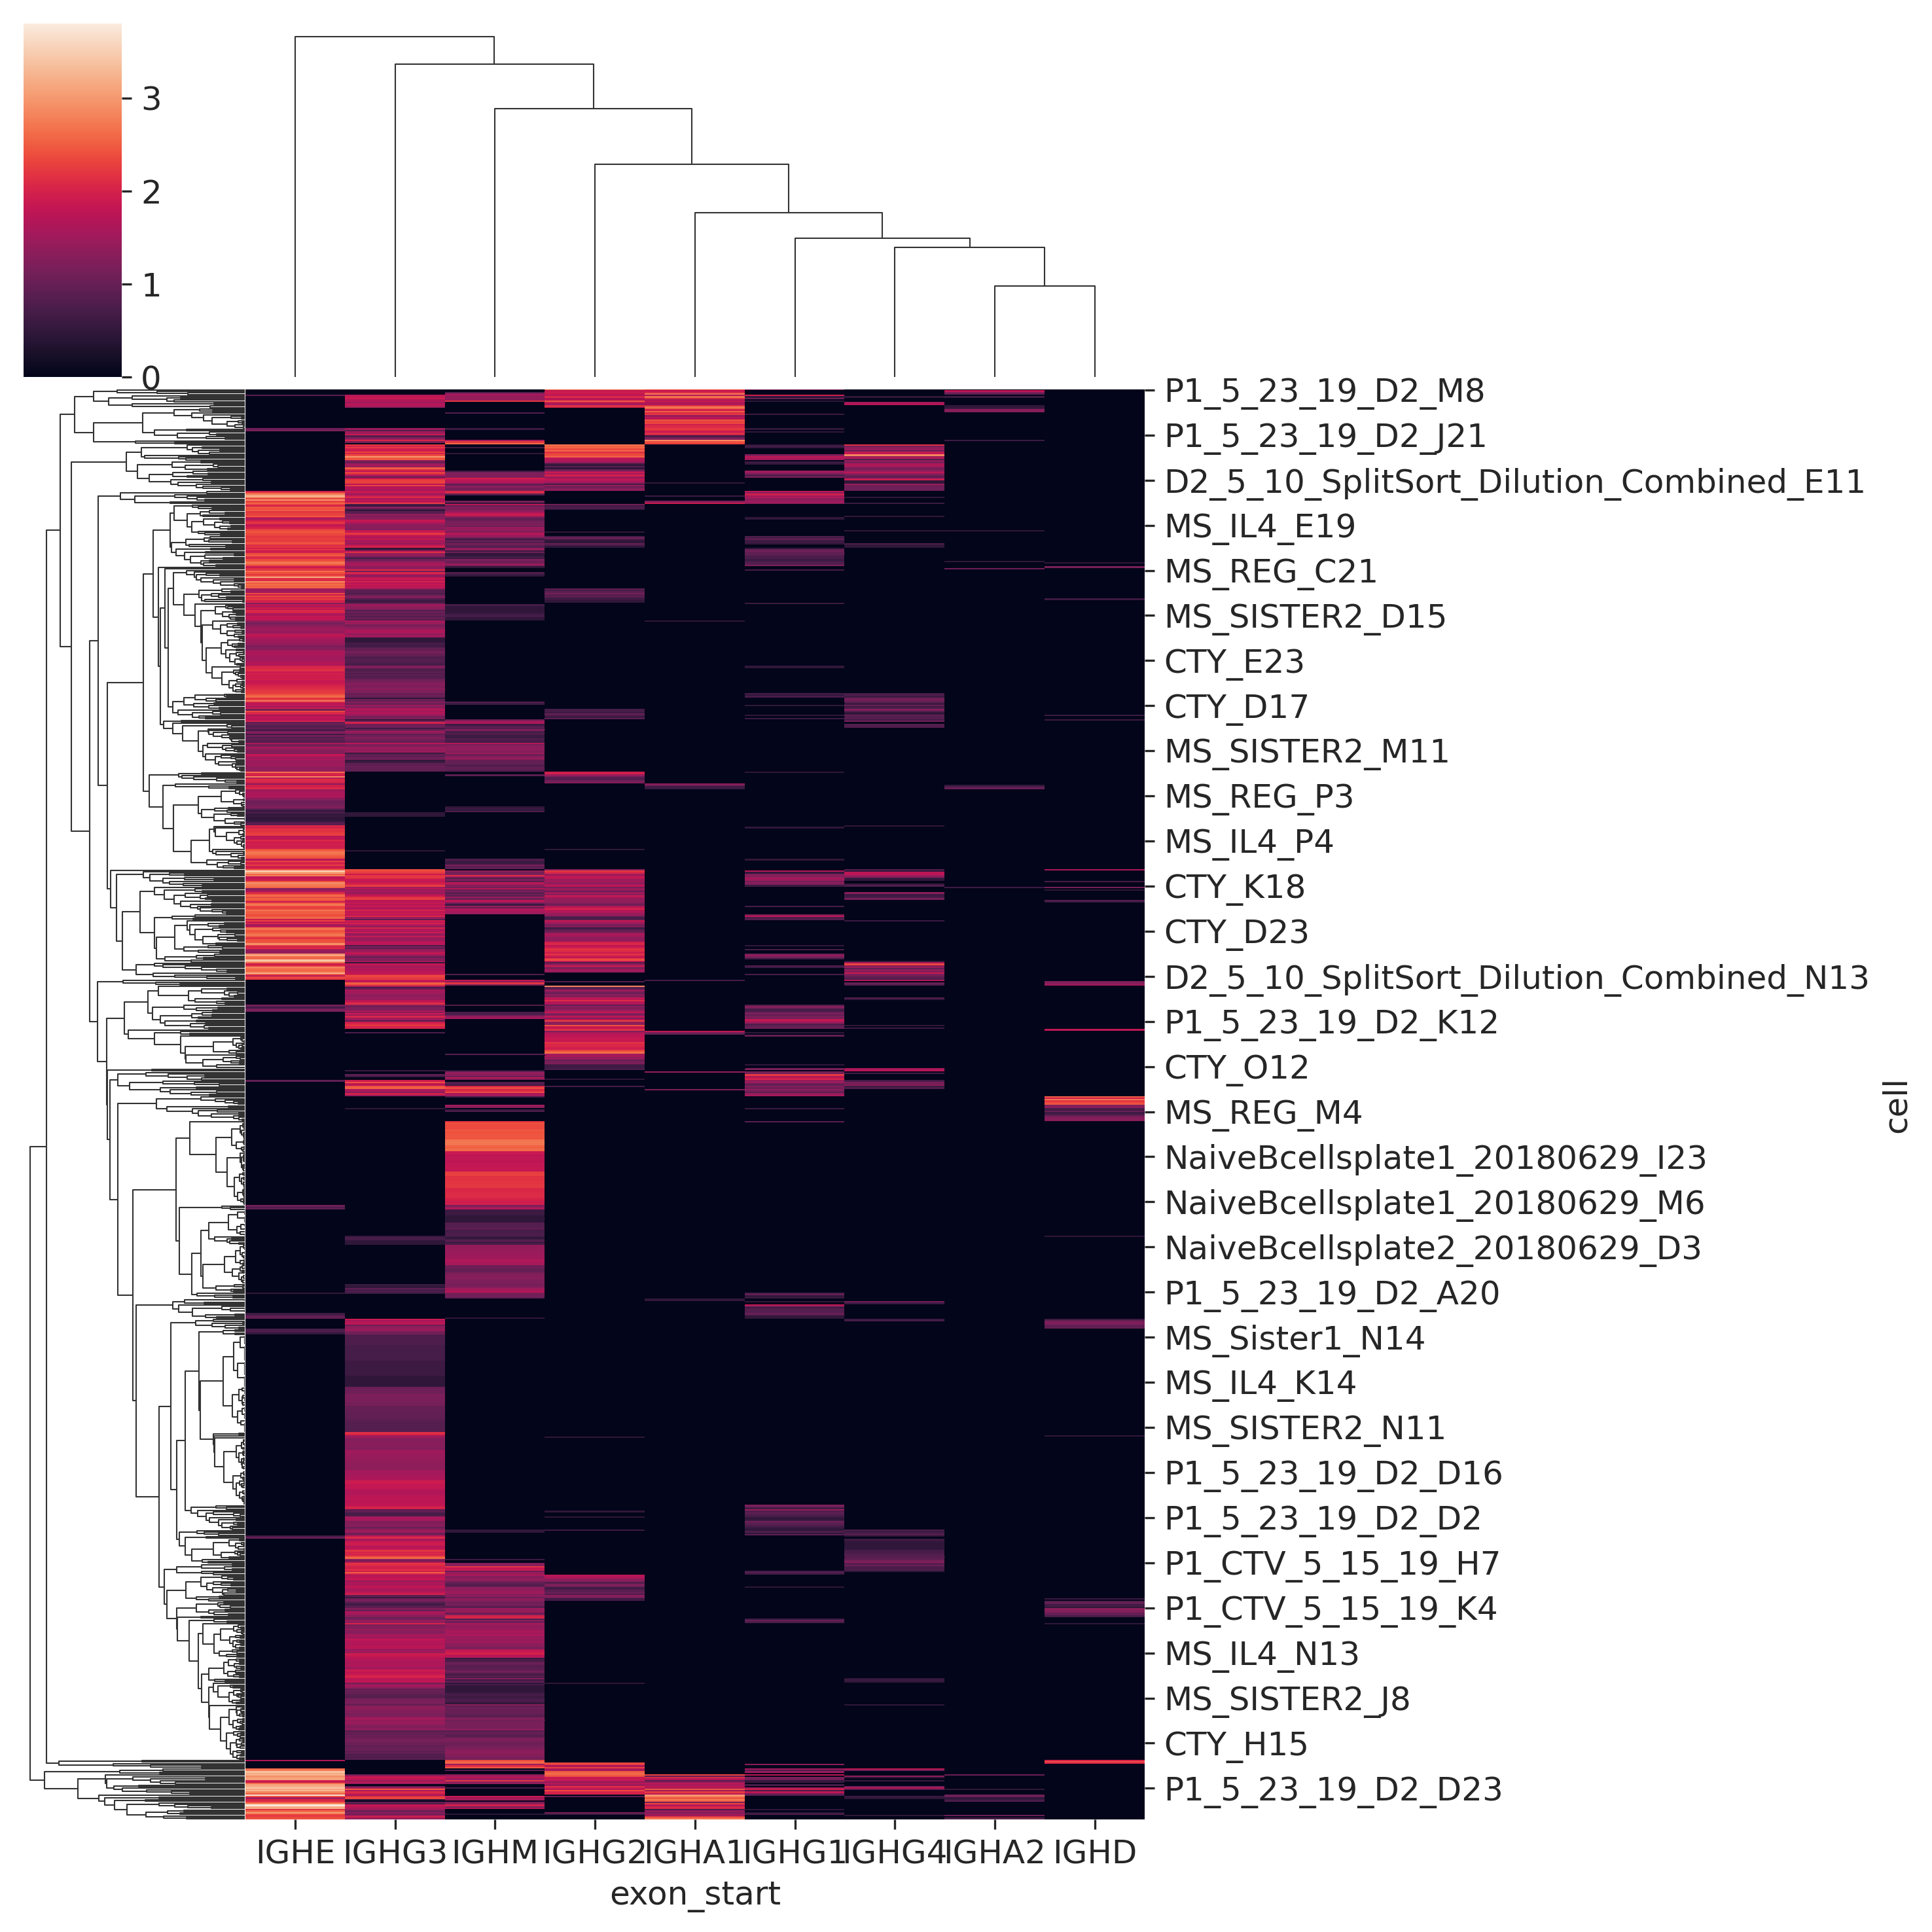

In [24]:
switchbysplice = plotheatmap(switch_tx)

# Attempt PCA

In [25]:
## Munging the switchbysplice df 

vals = switchbysplice.values
minmax = sklearn.preprocessing.minmax_scale(vals, axis = 1)
scaled = sklearn.preprocessing.scale(vals, axis = 1)

columns = switchbysplice.columns.to_list()

rows = switchbysplice.index.to_list()

df = pd.DataFrame(data = vals, index=rows, columns=columns)
df_norm =  pd.DataFrame(data = scaled, index=rows, columns=columns)

In [26]:
cells = df.index

In [27]:
pc = sklearn.decomposition.PCA().fit(df_norm)

In [28]:
dfr = pd.DataFrame(pc.transform(df)[:,:3], index = df.index, columns = ['PC1', 'PC2', 'PC3'])

In [29]:
_df = pd.merge(dfr, dfm, left_index = True, right_index = True)

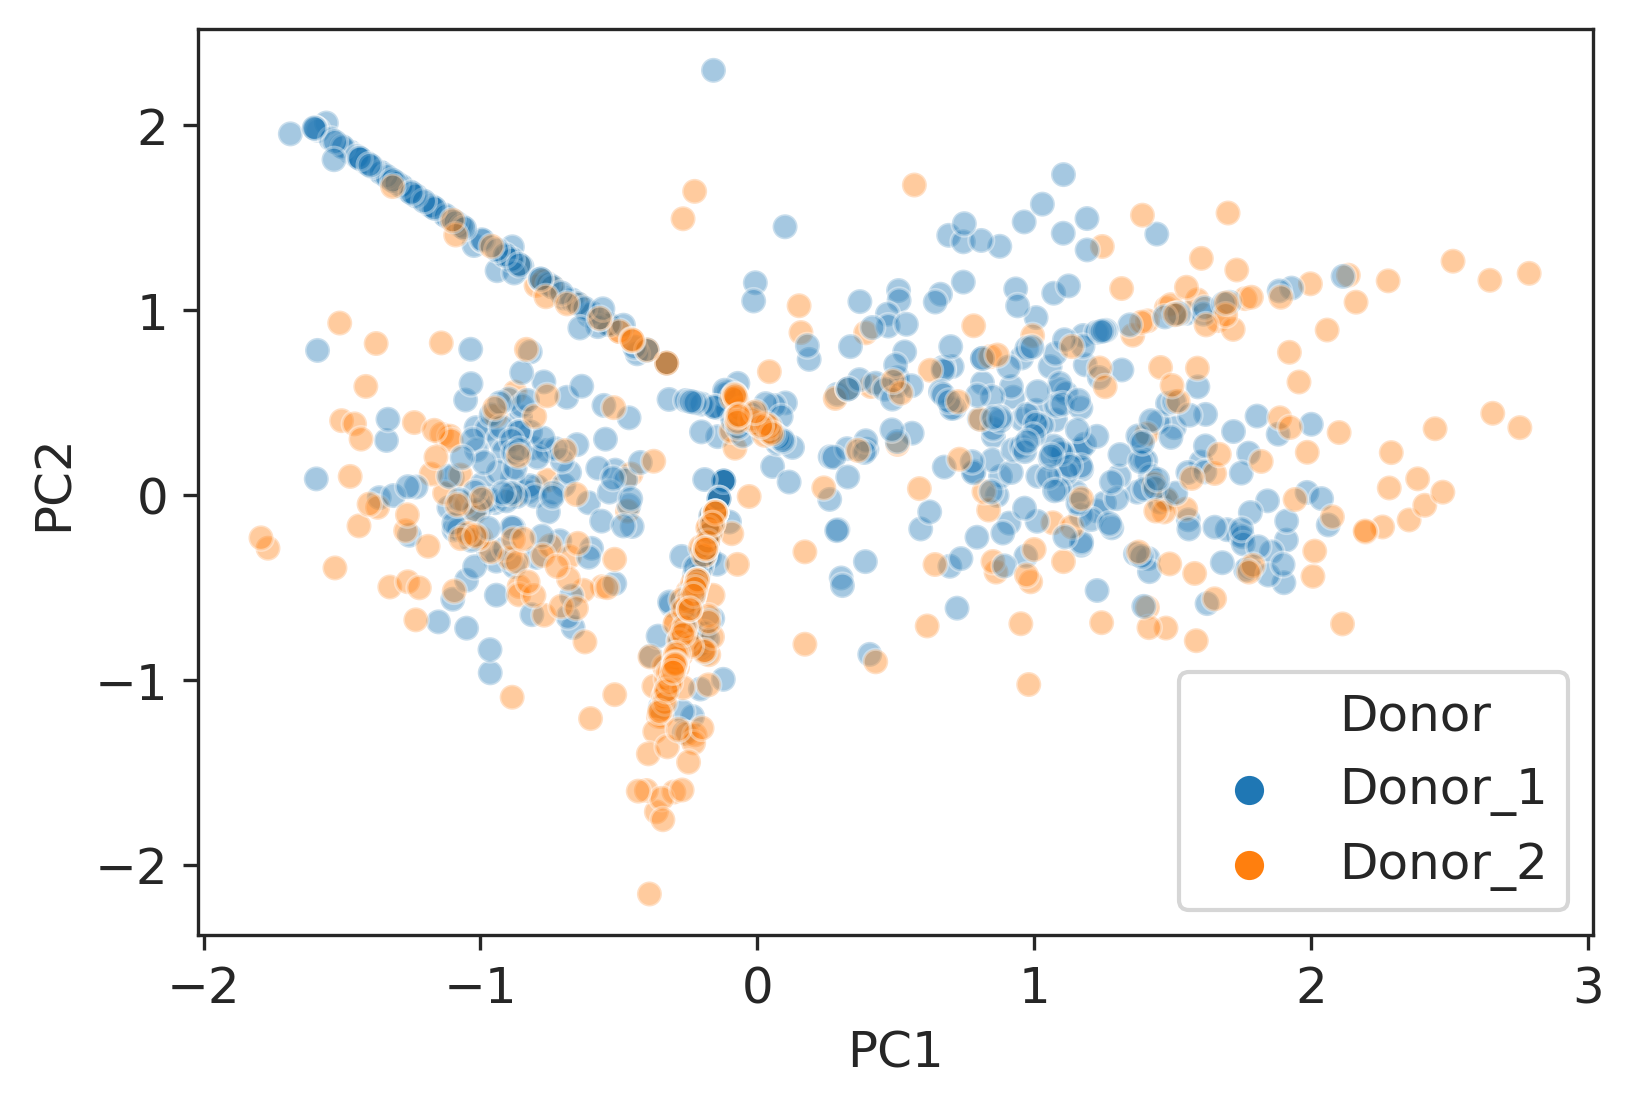

In [30]:
sns.scatterplot(x = _df['PC1'], y = _df['PC2'], hue=_df['Donor'], alpha = 0.4)

# Violin Plots

## Gene Counts Analysis

In [124]:
# Use only high quality cells
adata = sc.read_h5ad(data_dir + 'FilteredData.h5ad')
#adata.obs.index = adata.obs.index.str[:-2]
# Use Scanpy to filter for cells with good mapping and number of genes

In [47]:
ERCCs = adata.var.index[adata.var.index.str.contains('ERCC-')].to_list()

In [125]:
adata

AnnData object with n_obs × n_vars = 1350 × 14714
    obs: 'Donor', 'Experimental_Label', 'Treatment', 'Division_Number', 'CLONE', 'ISOTYPE', 'SEQUENCE_ID', 'Assembly', 'n_genes', 'n_counts'
    var: 'n_cells', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p'

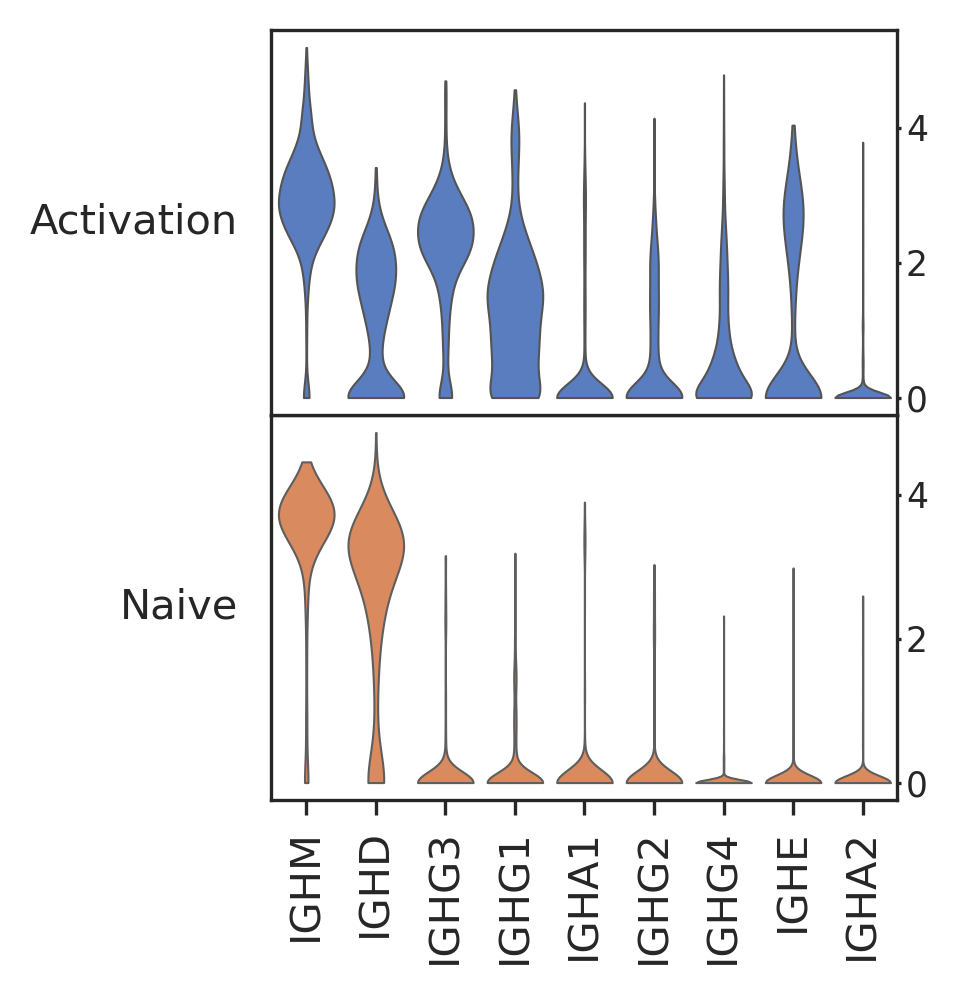

In [82]:
IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2']
sc.pl.stacked_violin(adata, var_names = IgH_genes, groupby='Treatment')

In [88]:
adata.obs.Division_Number.value_counts()

7      391
100    369
1      141
3      122
2       98
5       89
4       70
0       43
6       27
Name: Division_Number, dtype: int64

In [113]:
adata.obs.Treatment.value_counts()

Activation    986
Naive         364
Name: Treatment, dtype: int64

In [121]:
(adata.obs.groupby('Treatment').CLONE.value_counts() > 1).value_counts()

False    875
True     145
Name: CLONE, dtype: int64

In [111]:
adata.obs['Division_Category'] = adata.obs.Division_Number.astype('category')

IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2']
sc.pl.stacked_violin(adata, var_names = IgH_genes, groupby='Treatment', inner='box', save='TreatmentSwitchTx', )
sc.pl.stacked_violin(adata, var_names = IgH_genes, groupby='Division_Category', save='DivisionSwitchTx', inner = 'box', order=[100, 0, 1, 2, 3, 4, 5, 6, 7], figsize=[5,15])

In [43]:
# Munging the switchbysplice df 

vals = switchbysplice.values
minmax = sklearn.preprocessing.minmax_scale(vals, axis = 1)
columns = switchbysplice.columns.to_list()

rows = switchbysplice.index.to_list()

df = pd.DataFrame(data = vals, index=rows, columns=columns)
df_norm =  pd.DataFrame(data = minmax, index=rows, columns=columns)

In [103]:
switchbysplice

exon_start,IGHA1,IGHA2,IGHD,IGHE,IGHG1,IGHG2,IGHG3,IGHG4,IGHM
cell,,,,,,,,,
CTY_A10,0.0,0.0,0.0,1.431364,0.000000,0.698970,0.903090,0.0,0.000000
CTY_A12,0.0,0.0,0.0,2.004321,0.477121,0.000000,0.000000,0.0,0.000000
CTY_A13,0.0,0.0,0.0,2.225309,0.000000,0.000000,1.633468,0.0,0.602060
CTY_A14,0.0,0.0,0.0,1.875061,1.113943,0.000000,1.662758,0.0,0.602060
CTY_A20,0.0,0.0,0.0,0.000000,0.778151,0.477121,0.954243,0.0,0.000000
...,...,...,...,...,...,...,...,...,...
P1_CTV_5_15_19_P11,0.0,0.0,0.0,1.568202,0.000000,0.000000,1.518514,0.0,0.000000
P1_CTV_5_15_19_P12,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.770852,0.0,0.000000
P1_CTV_5_15_19_P16,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.819544,0.0,0.000000


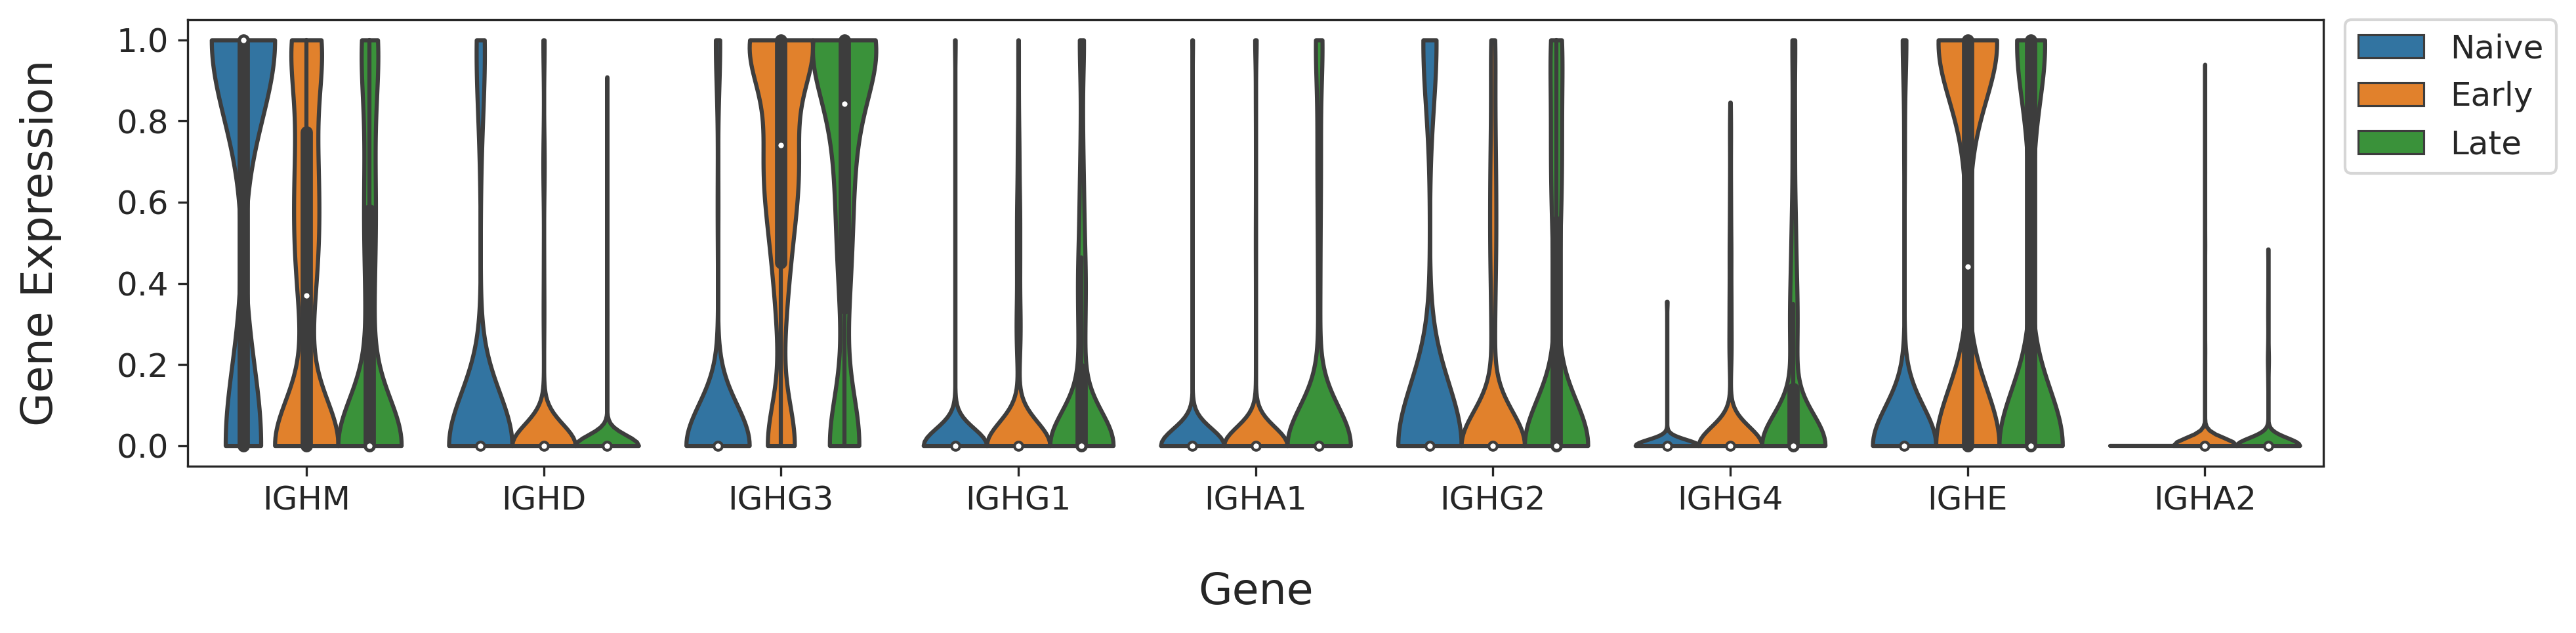

In [44]:
# Switch Transcripts Quantification

df_GeneExpression = df_norm

EarlyStim = df_GeneExpression[~df_GeneExpression.index.str.contains('Dilution|5_15_19|5_23|Naive|IL6|PASL|B107|AgSeq')]
#AllStim = df_GeneExpression[~df_GeneExpression.index.str.contains('Naive|PASL|AgSeq|B1079')]
LateStim =  df_GeneExpression[df_GeneExpression.index.str.contains('Dilution|5_15|5_23')]
Naive =  df_GeneExpression[df_GeneExpression.index.str.contains('Naive')]


dfs = [Naive, EarlyStim, LateStim]

Timepoints = ['Naive', 'Early', "Late"]
violins = []
for i, df in enumerate(dfs):
    
    data = df.unstack()

    data = data.reset_index()

    data.columns = ['Gene', 'Cell', 'Expression']
    data['Timepoint'] = Timepoints[i]
    violins.append(data)
    
cat_vio = pd.concat(violins)

data = cat_vio
fig, ax = plt.subplots(1,1, figsize = (14,3))

ax = sns.violinplot(data = data, order = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', "IGHA1", "IGHG2", 'IGHG4', 'IGHE', 'IGHA2'], scale='width', cut = 0, y = 'Expression', x ="Gene", hue = 'Timepoint', figsize = (10, 20))
h = plt.ylabel('Gene Expression', fontsize = 16, rotation = 90, labelpad = 20)
plt.xticks(fontsize=12, rotation = 0)
plt.yticks(fontsize=12, rotation = 0)
plt.xlabel("Gene", fontsize=16, rotation = 0, labelpad=20)
plt.legend(bbox_to_anchor = (1.01, 1), loc = 2, borderaxespad = 0)